In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
print("Notebook çalışıyor")

Notebook çalışıyor


In [2]:
df = pd.read_csv("../data/student.csv")

df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

In [4]:
X = df.drop(columns=["exam_score", "student_id"])
y = df["exam_score"]

In [5]:

dataset_name = "student.csv"

print("\n" + "="*80)
print(f"📊 DATA QUALITY AUDIT: {dataset_name}")
print("="*80)

# Basic info
print(f"\n1. DATASET DIMENSIONS:")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

# Column names
print(f"\n2. ACTUAL COLUMN NAMES:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. '{col}'")

# Data types
print(f"\n3. DATA TYPES:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

print(f"\n   Numeric columns: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"   Categorical columns: {len(df.select_dtypes(include=['object']).columns)}")

# Missing values
print(f"\n4. MISSING VALUES ANALYSIS:")
missing = df.isnull().sum()
total_missing = missing.sum()
print(f"   Total missing: {total_missing:,}")

if total_missing > 0:
    missing_pct = 100 * missing / len(df)
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing': missing.values,
        'Percent': missing_pct.values
    }).sort_values('Missing', ascending=False)
    display(missing_df[missing_df['Missing'] > 0].head(15))
else:
    print("   ✅ No missing values detected!")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\n5. DUPLICATE ROWS: {duplicates:,}")

# Sample data
print(f"\n6. SAMPLE DATA (First 5 Rows):")
display(df.head())

# Statistical summary
print(f"\n7. STATISTICAL SUMMARY (Numeric Columns):")
display(df.describe().T)

# Categorical summary
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if len(cat_cols) > 0:
    print(f"\n8. CATEGORICAL COLUMNS SUMMARY:")
    for col in cat_cols:
        unique_count = df[col].nunique()
        top_values = df[col].value_counts().head(5)
        print(f"\n   Column: {col}")
        print(f"   Unique values: {unique_count}")
        print(f"   Top 5 values:\n{top_values}")

print("\n" + "="*80)
print("✅ AUDIT COMPLETE")
print("="*80 + "\n")


📊 DATA QUALITY AUDIT: student.csv

1. DATASET DIMENSIONS:
   Rows: 5,000
   Columns: 21
   Memory: 1.61 MB

2. ACTUAL COLUMN NAMES:
    1. 'student_id'
    2. 'age'
    3. 'gender'
    4. 'academic_level'
    5. 'study_hours'
    6. 'self_study_hours'
    7. 'online_classes_hours'
    8. 'social_media_hours'
    9. 'gaming_hours'
   10. 'sleep_hours'
   11. 'screen_time_hours'
   12. 'exercise_minutes'
   13. 'caffeine_intake_mg'
   14. 'part_time_job'
   15. 'upcoming_deadline'
   16. 'internet_quality'
   17. 'mental_health_score'
   18. 'focus_index'
   19. 'burnout_level'
   20. 'productivity_score'
   21. 'exam_score'

3. DATA TYPES:
   float64: 11 columns
   int64: 7 columns
   object: 3 columns

   Numeric columns: 18
   Categorical columns: 3

4. MISSING VALUES ANALYSIS:
   Total missing: 0
   ✅ No missing values detected!

5. DUPLICATE ROWS: 0

6. SAMPLE DATA (First 5 Rows):


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81



7. STATISTICAL SUMMARY (Numeric Columns):


,count,mean,std,min,25%,50%,75%,max
student_id,5000.0,2500.500000,1443.520003,1.0,1250.7500,2500.50,3750.2500,5000.00
age,5000.0,20.520400,2.870406,16.0,18.0000,20.00,23.0000,25.00
study_hours,5000.0,4.539594,1.821665,0.0,3.2500,4.53,5.7600,11.84
self_study_hours,5000.0,2.478734,1.177990,0.0,1.6600,2.48,3.2900,7.41
online_classes_hours,5000.0,2.011984,0.983906,0.0,1.3200,2.01,2.6900,6.00
social_media_hours,5000.0,2.998086,1.467949,0.0,1.9900,2.98,4.0300,8.28
gaming_hours,5000.0,1.564514,1.110807,0.0,0.6700,1.49,2.3400,5.64
sleep_hours,5000.0,7.016492,1.163692,4.0,6.2375,7.01,7.8100,10.00
screen_time_hours,5000.0,6.979588,2.486214,1.0,5.2800,6.95,8.7100,15.30
exercise_minutes,5000.0,74.535600,42.932293,0.0,37.0000,75.00,112.0000,149.00



8. CATEGORICAL COLUMNS SUMMARY:

   Column: gender
   Unique values: 3
   Top 5 values:
gender
Male      1719
Other     1651
Female    1630
Name: count, dtype: int64

   Column: academic_level
   Unique values: 3
   Top 5 values:
academic_level
Postgraduate     1687
High School      1672
Undergraduate    1641
Name: count, dtype: int64

   Column: internet_quality
   Unique values: 3
   Top 5 values:
internet_quality
Good       1722
Poor       1640
Average    1638
Name: count, dtype: int64

✅ AUDIT COMPLETE



In [6]:
# Missing values count
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_percent
}).sort_values("Missing_Count", ascending=False)

missing_df

,Missing_Count,Missing_Percent
student_id,0,0.0
age,0,0.0
gender,0,0.0
academic_level,0,0.0
study_hours,0,0.0
self_study_hours,0,0.0
online_classes_hours,0,0.0
social_media_hours,0,0.0
gaming_hours,0,0.0
sleep_hours,0,0.0


In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['student_id', 'age', 'study_hours', 'self_study_hours',
       'online_classes_hours', 'social_media_hours', 'gaming_hours',
       'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'mental_health_score', 'focus_index', 'burnout_level',
       'productivity_score', 'exam_score'],
      dtype='object')

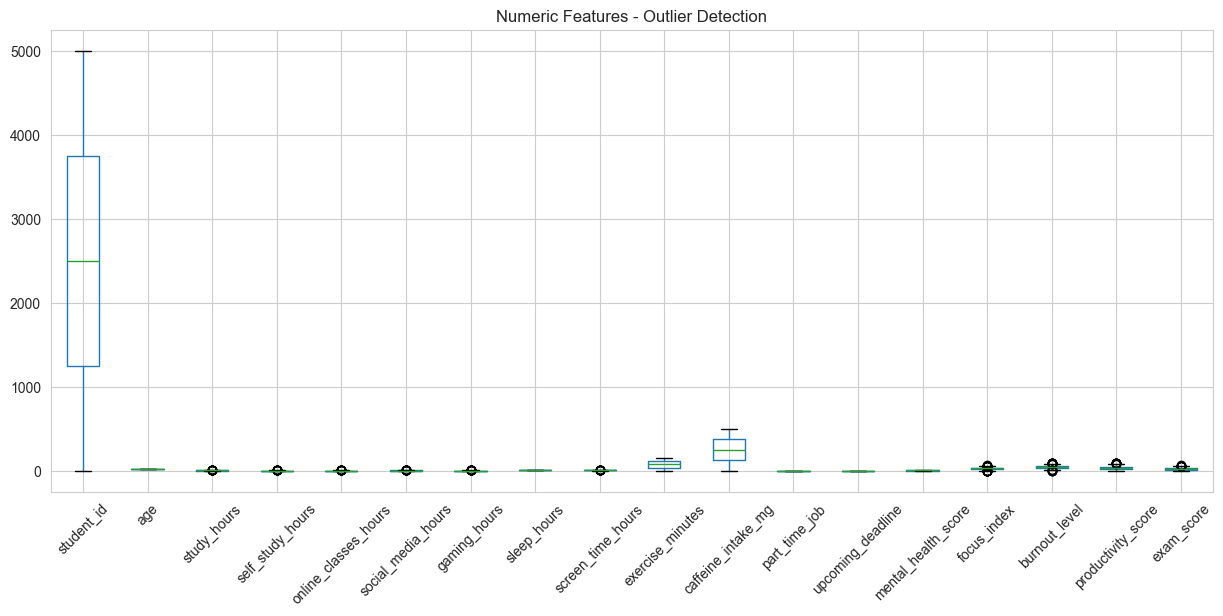

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
df[numeric_cols].boxplot(rot=45)
plt.title("Numeric Features - Outlier Detection")
plt.show()

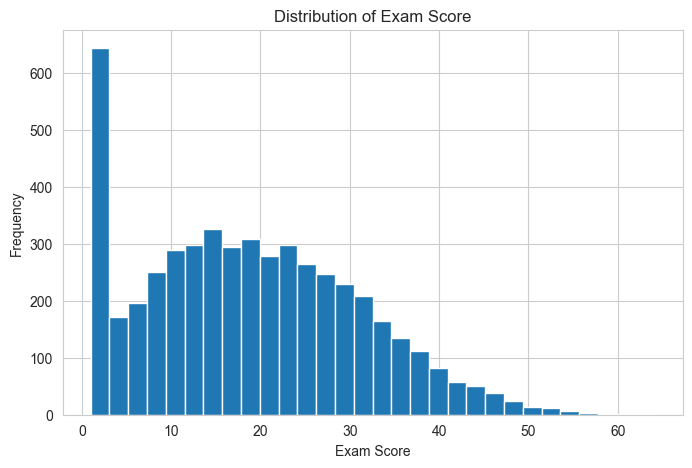

In [9]:
plt.figure(figsize=(8,5))
df["exam_score"].hist(bins=30)
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

Exam skoru normal dağılım göstermektedir.Regresyon temelli modeller için uygunluk sağlamaktadır.

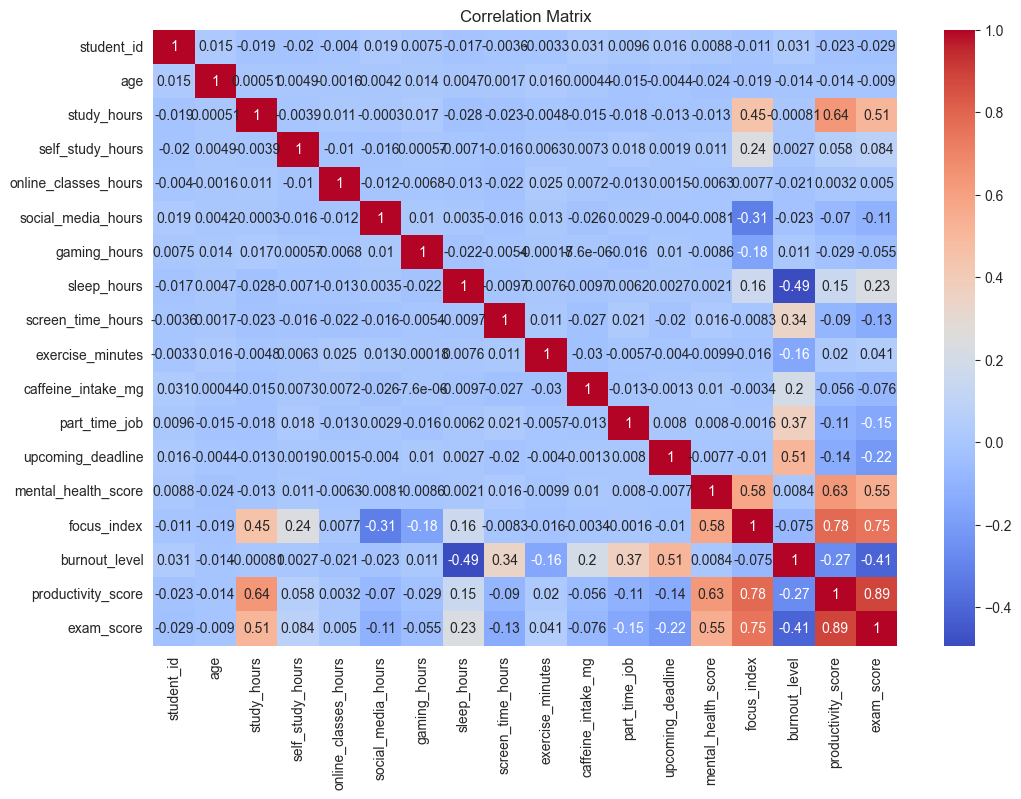

In [10]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [11]:
df["burnout_level"].value_counts()

burnout_level
48.08    6
42.92    5
41.69    5
52.14    5
47.26    5
        ..
70.91    1
46.29    1
56.04    1
21.01    1
50.72    1
Name: count, Length: 3256, dtype: int64

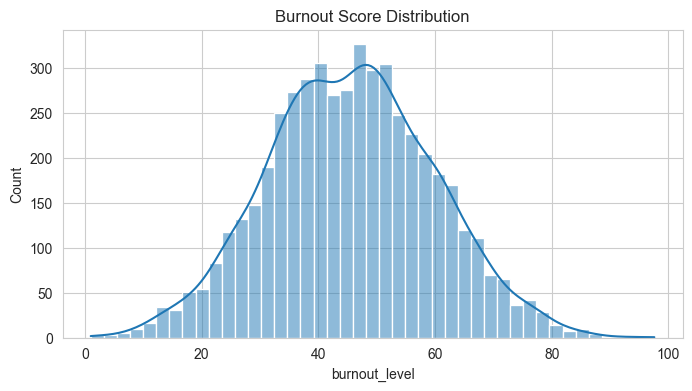

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df["burnout_level"], kde=True)
plt.title("Burnout Score Distribution")
plt.show()

In [13]:
df["burnout_level"].describe()

count    5000.000000
mean       45.615324
std        14.246591
min         1.000000
25%        35.727500
50%        45.690000
75%        55.352500
max        97.580000
Name: burnout_level, dtype: float64

Dağılım oldukça simetrik ve dengeli görünüyor.

Verinin %50’si 35 – 55 aralığında

55 üzeri zaten üst çeyrek

70+ muhtemelen ciddi azınlık


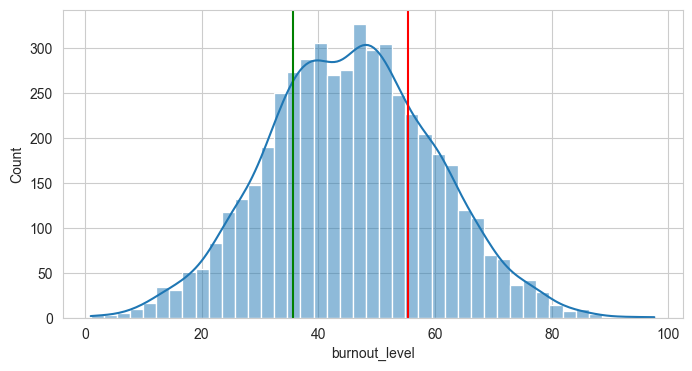

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(df["burnout_level"], kde=True)
plt.axvline(35.7, color="green")
plt.axvline(55.35, color="red")
plt.show()

In [15]:
df_clean = df.copy()

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_feature_vs_exam(feature_name):

    if feature_name not in df_clean.columns:
        print(f"{feature_name} bulunamadı.")
        return

    corr = df_clean[feature_name].corr(df_clean["exam_score"])

    print("="*60)
    print(f"{feature_name.upper()} vs EXAM SCORE")
    print("="*60)
    print(f"Correlation (r): {round(corr,3)}")

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Scatter
    axes[0].scatter(df_clean[feature_name], df_clean["exam_score"], alpha=0.5)
    axes[0].set_xlabel(feature_name)
    axes[0].set_ylabel("Exam Score")
    axes[0].set_title(f"{feature_name} vs Exam Score")

    # Binning
    df_clean["temp_bins"] = pd.cut(df_clean[feature_name], bins=5)
    binned_mean = df_clean.groupby("temp_bins")["exam_score"].mean()

    binned_mean.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Average Exam Score (Binned)")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

STUDY_HOURS vs EXAM SCORE
Correlation (r): 0.513


C:\Users\yusra\AppData\Local\Temp\ipykernel_18168\2146899457.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_mean = df_clean.groupby("temp_bins")["exam_score"].mean()


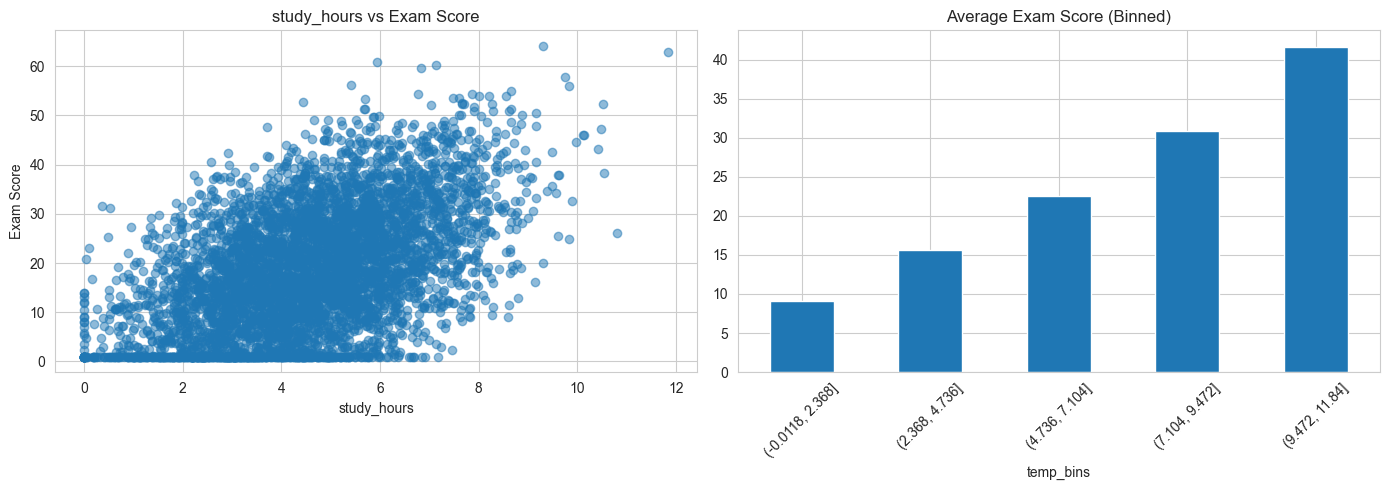

In [17]:
analyze_feature_vs_exam("study_hours")

SLEEP_HOURS vs EXAM SCORE
Correlation (r): 0.235


C:\Users\yusra\AppData\Local\Temp\ipykernel_18168\2146899457.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_mean = df_clean.groupby("temp_bins")["exam_score"].mean()


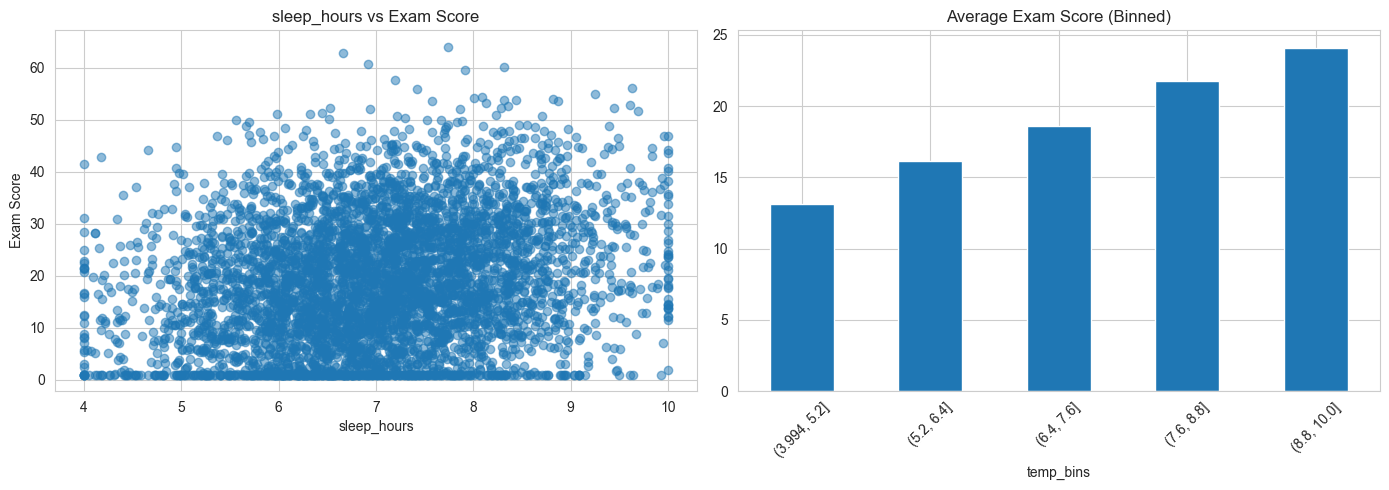

In [18]:
analyze_feature_vs_exam("sleep_hours")

MENTAL_HEALTH_SCORE vs EXAM SCORE
Correlation (r): 0.547


C:\Users\yusra\AppData\Local\Temp\ipykernel_18168\2146899457.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_mean = df_clean.groupby("temp_bins")["exam_score"].mean()


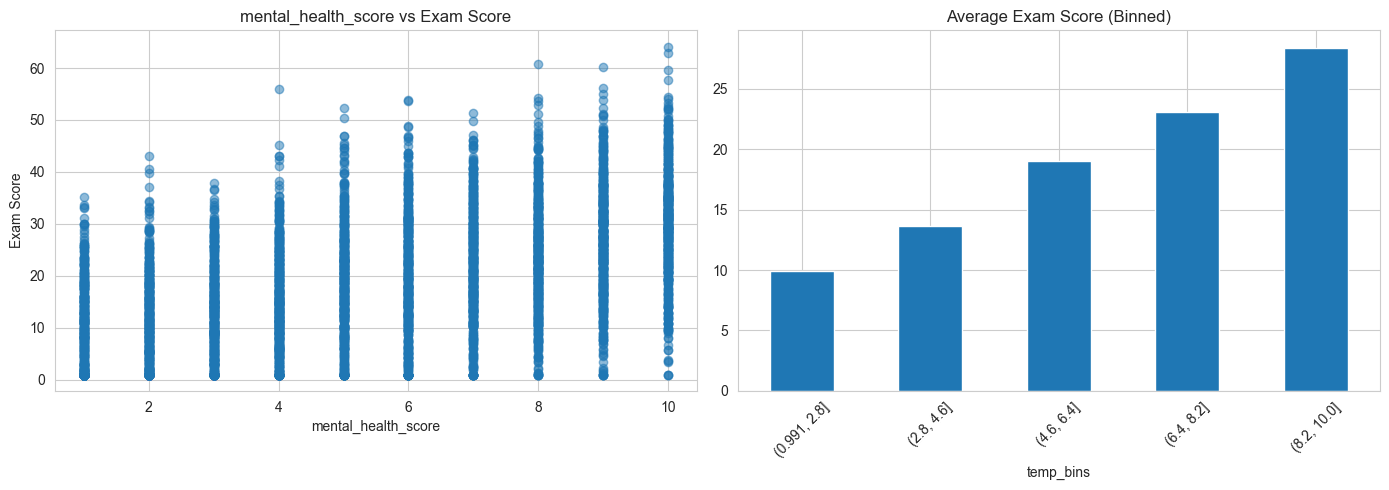

In [19]:
analyze_feature_vs_exam("mental_health_score")

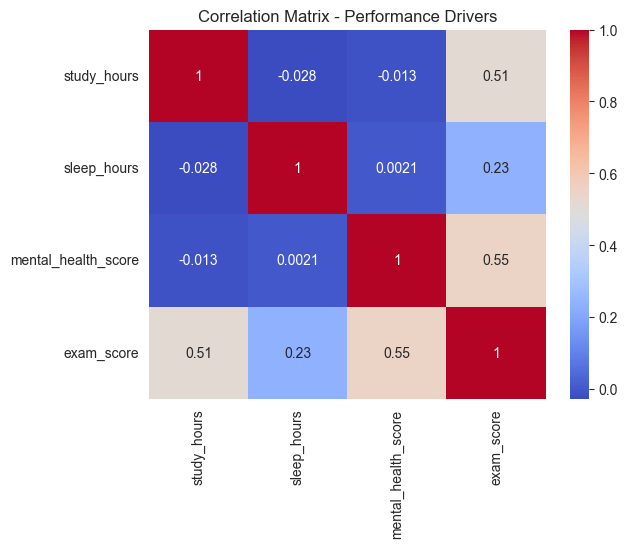

In [20]:
features = ["study_hours", "sleep_hours", "mental_health_score"]
corr_matrix = df_clean[features + ["exam_score"]].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - Performance Drivers")
plt.show()

Birincil performans sürücülerini belirlemek için korelasyon tabanlı bir keşif analizi yapıldı.Çalışma saati ve ruh sağlığı akademik başarı ile pozitif ilişki sergiledi.Uyku doğrusal olmayan optimal bir aralık gösterdi.

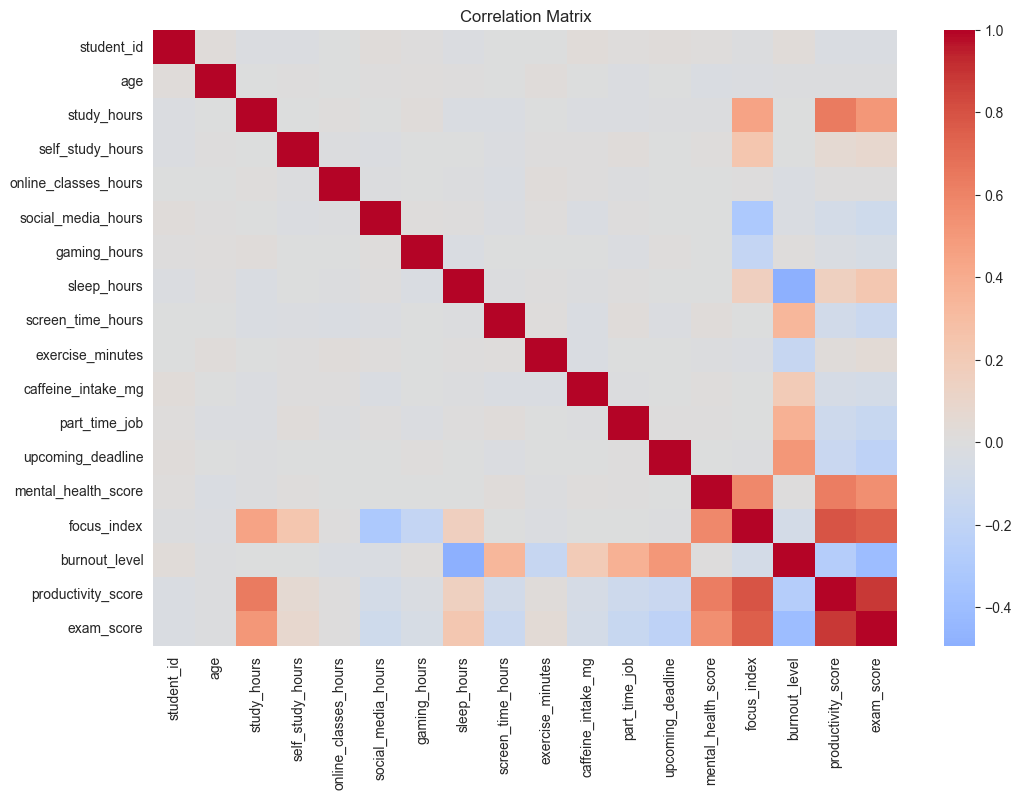

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [22]:
df["burnout_category"] = pd.cut(
    df["burnout_level"],
    bins=[0, 35, 55, 100],
    labels=["Low", "Medium", "High"]
)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pickle
feature_columns = [
    "study_hours",
    "sleep_hours",
    "mental_health_score",
    "screen_time_hours",
    "social_media_hours",
    "part_time_job",
    "upcoming_deadline"
]
X = df[feature_columns]
y = df["burnout_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42,class_weight="balanced")
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

# Kaydet
with open("burnout_classifier.pkl", "wb") as f:
    pickle.dump(model, f)

              precision    recall  f1-score   support

        High       0.75      0.69      0.72       253
         Low       0.77      0.61      0.68       235
      Medium       0.71      0.80      0.75       512

    accuracy                           0.73      1000
   macro avg       0.74      0.70      0.72      1000
weighted avg       0.73      0.73      0.73      1000



In [24]:
print(df["burnout_category"].value_counts())

burnout_category
Medium    2566
High      1277
Low       1157
Name: count, dtype: int64


In [25]:
importances = model.feature_importances_
for f, imp in zip(feature_columns, importances):
    print(f"{f}: {imp:.3f}")

study_hours: 0.119
sleep_hours: 0.268
mental_health_score: 0.065
screen_time_hours: 0.194
social_media_hours: 0.114
part_time_job: 0.082
upcoming_deadline: 0.159


In [26]:
df_feat = df_clean.copy()
actual_cols = df_feat.columns.tolist()
feature_count = 0

# Feature 1: Total screen time
if 'social_media_hours' in actual_cols and 'gaming_hours' in actual_cols:
    df_feat['total_leisure_screen_time'] = df_feat['social_media_hours'] + df_feat['gaming_hours']
    feature_count += 1
    print(f"✅ Created total_leisure_screen_time")
if 'study_hours' in actual_cols and 'self_study_hours' in actual_cols:
    df_feat['self_study_ratio'] = df_feat['self_study_hours'] / (df_feat['study_hours'] + 1)
    feature_count += 1
    print(f"✅ Created self_study_ratio")
if 'sleep_hours' in actual_cols:
    df_feat['sleep_category'] = pd.cut(df_feat['sleep_hours'], bins=[0, 6, 8, 12], labels=['Low', 'Optimal', 'High'])
    
if 'exercise_minutes' in actual_cols:
    df_feat['exercise_category'] = pd.cut(df_feat['exercise_minutes'], bins=[0, 30, 60, 200], labels=['Low', 'Moderate', 'High'])

if 'caffeine_intake_mg' in actual_cols:
    df_feat['caffeine_category'] = pd.cut(df_feat['caffeine_intake_mg'], bins=[0, 100, 300, 500], labels=['Low', 'Moderate', 'High'])
if 'sleep_hours' in actual_cols:
    df_feat['sleep_deficit'] = np.abs(df_feat['sleep_hours'] - 8.0)
    
    feature_count += 1
    print(f"✅ Created sleep_deficit")
if 'study_hours' in actual_cols and 'screen_time_hours' in actual_cols:
    df_feat['study_screen_ratio'] = df_feat['study_hours'] / (df_feat['screen_time_hours'] + 1)
    feature_count += 1
    print(f"✅ Created study_screen_ratio")
if 'exercise_minutes' in actual_cols:
    df_feat['exercise_category'] = pd.cut(df_feat['exercise_minutes'], bins=[0, 30, 60, 200], labels=['Low', 'Moderate', 'High'])
    df_feat['is_active'] = (df_feat['exercise_minutes'] >= 30).astype(int)
    feature_count += 2
    print(f"✅ Created exercise_category and is_active")
if 'caffeine_intake_mg' in actual_cols:
    df_feat['high_caffeine'] = (df_feat['caffeine_intake_mg'] > 200).astype(int)
    
    feature_count += 1
    print(f"✅ Created high_caffeine and caffeine_category")
if 'upcoming_deadline' in actual_cols and 'part_time_job' in actual_cols:
    df_feat['high_stress'] = (df_feat['upcoming_deadline'] & df_feat['part_time_job']).astype(int)
    feature_count += 1
    print(f"✅ Created high_stress indicator")
if 'focus_index' in actual_cols and 'study_hours' in actual_cols:
    df_feat['focus_per_study_hour'] = df_feat['focus_index'] / (df_feat['study_hours'] + 1)
    feature_count += 1
    print(f"✅ Created focus_per_study_hour")

print(f"   Original features: {len(df_clean.columns)}")
print(f"   New features: {feature_count}")
print(f"   Total features: {len(df_feat.columns)}")
print("\n")

✅ Created total_leisure_screen_time
✅ Created self_study_ratio
✅ Created sleep_deficit
✅ Created study_screen_ratio
✅ Created exercise_category and is_active
✅ Created high_caffeine and caffeine_category
✅ Created high_stress indicator
✅ Created focus_per_study_hour
   Original features: 22
   New features: 9
   Total features: 33




In [27]:
# df_feat'e burnout_category kolonunu ekle
df_feat["burnout_category"] = pd.cut(
    df_feat["burnout_level"],
    bins=[0, 35, 55, 100],
    labels=["Low", "Medium", "High"]
)

In [28]:
categorical_cols = ["sleep_category", "exercise_category", "caffeine_category"]
df_model = pd.get_dummies(df_feat[feature_columns + categorical_cols + ["burnout_category"]], drop_first=True)

Kategorik kolonları one-hot encode edildi.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Stratify: sınıf dengesini korur, burnout sınıflarında dengeli test/train set oluşturur.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pickle

model = RandomForestClassifier(random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        High       0.76      0.67      0.71       256
         Low       0.69      0.66      0.67       231
      Medium       0.70      0.76      0.73       513

    accuracy                           0.71      1000
   macro avg       0.72      0.70      0.70      1000
weighted avg       0.71      0.71      0.71      1000



RandomForest eğitimi yapıldı.Accuracy değeri model verinin ne kadarlık kısmını doğru sınıflandırdığını gösteriyor.
High burn_out:F1 score 0.71 yüksek burnout riskindeki öğrencileri tahmin etmede orta seviyede başarılı
Medium burnout:F1 score 0.73 orta risk grubunu daha iyi yakalıyor.
Low burnout:0.67 risk grubu biraz daha zor tahmin ediliyor.

In [31]:
import pickle

with open("burnout_classifier.pkl", "rb") as f:
    model = pickle.load(f)

# Kullanıcıdan gelen feature verisiyle tahmin


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import pandas as pd

# Sayısal feature’lar
numeric_features = [
    "study_hours",
    "self_study_ratio",
    "sleep_deficit",
    "study_screen_ratio",
    "total_leisure_screen_time",
    "is_active",
    "high_caffeine",
    "high_stress",
    "focus_per_study_hour",
    
]

# Kategorik feature’lar (one-hot encode edilecek)
categorical_cols = ["sleep_category", "exercise_category", "caffeine_category"]

# Model dataframe’i oluştur
df_model = pd.get_dummies(df_feat[numeric_features + categorical_cols + ["productivity_score", "focus_index"]], drop_first=True)

Burnout modelinde kullandığımız özellikler çoğunlukla sayısal ve uygun,bazı kategorikleri de one-hot encode edildi

In [33]:
# Hedef ve feature ayrımı
X_prod = df_model.drop(columns=["productivity_score", "focus_index"])  # Diğer hedefi çıkarıyoruz
y_prod = df_model["productivity_score"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_prod, y_prod, test_size=0.2, random_state=42
)

# RandomForestRegressor
prod_model = RandomForestRegressor(random_state=42, n_estimators=200)
prod_model.fit(X_train, y_train)

# Tahmin ve performans
y_pred = prod_model.predict(X_test)
print("Productivity Score Model Performance:")
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")
#print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.3f}")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.3f}")
# Kaydet
with open("productivity_model.pkl", "wb") as f:
    pickle.dump(prod_model, f)

Productivity Score Model Performance:
R2 Score: 0.725
RMSE: 8.456


In [34]:
# Hedef ve feature ayrımı
X_focus = df_model.drop(columns=["focus_index", "productivity_score"])
y_focus = df_model["focus_index"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_focus, y_focus, test_size=0.2, random_state=42
)

# RandomForestRegressor
focus_model = RandomForestRegressor(random_state=42, n_estimators=200)
focus_model.fit(X_train, y_train)

# Tahmin ve performans
y_pred = focus_model.predict(X_test)
print("Focus Index Model Performance:")
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")
#print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.3f}")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.3f}")
# Kaydet
with open("focus_model.pkl", "wb") as f:
    pickle.dump(focus_model, f)

Focus Index Model Performance:
R2 Score: 0.992
RMSE: 0.891


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


def train_and_compare_models(df_model, target_column, model_save_name):

    print("\n" + "="*80)
    print(f"🎯 TARGET: {target_column}")
    print("="*80)

    X = df_model.drop(columns=[target_column])
    y = df_model[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        "LinearRegression": LinearRegression(),
        "DecisionTree": DecisionTreeRegressor(random_state=42),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42)
    }

    results = []

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)

        rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        mae = mean_absolute_error(y_test, test_pred)

        results.append({
            "model_name": name,
            "model_object": model,
            "train_r2": train_r2,
            "test_r2": test_r2,
            "test_rmse": rmse,
            "test_mae": mae
        })

        print(f"Train R²: {train_r2:.4f}")
        print(f"Test R²:  {test_r2:.4f}")
        print(f"RMSE:     {rmse:.4f}")
        print(f"MAE:      {mae:.4f}")
        print(f"Overfit:  {train_r2 - test_r2:.4f}")

    # 📊 Comparison Table
    comparison = pd.DataFrame([{
        "Model": r["model_name"],
        "Train R²": r["train_r2"],
        "Test R²": r["test_r2"],
        "RMSE": r["test_rmse"],
        "MAE": r["test_mae"],
        "Overfit": r["train_r2"] - r["test_r2"]
    } for r in results])

    comparison = comparison.sort_values("Test R²", ascending=False)

    print("\n" + "="*80)
    print("📊 MODEL COMPARISON")
    print("="*80)
    display(comparison)

    # 🏆 Best Model
    best_model_name = comparison.iloc[0]["Model"]
    best_result = next(r for r in results if r["model_name"] == best_model_name)
    best_model = best_result["model_object"]

    print(f"\n🏆 BEST MODEL: {best_model_name}")
    print(f"Test R²: {best_result['test_r2']:.4f}")
    print(f"RMSE: {best_result['test_rmse']:.4f}")
    print(f"MAE: {best_result['test_mae']:.4f}")

    # 📈 Visualization
    plt.figure(figsize=(10, 5))
    x_pos = np.arange(len(comparison))
    plt.bar(x_pos, comparison["Test R²"])
    plt.xticks(x_pos, comparison["Model"], rotation=45)
    plt.ylabel("Test R²")
    plt.title(f"{target_column} - Model Comparison")
    plt.tight_layout()
    plt.show()

    # 💾 Save Best Model
    with open(model_save_name, "wb") as f:
        pickle.dump(best_model, f)

    print(f"\n✅ Best model saved as {model_save_name}")

    return best_model


🎯 TARGET: productivity_score

🔹 Training LinearRegression...
Train R²: 0.7832
Test R²:  0.7536
RMSE:     8.0112
MAE:      6.4129
Overfit:  0.0296

🔹 Training DecisionTree...
Train R²: 1.0000
Test R²:  0.4605
RMSE:     11.8532
MAE:      9.2899
Overfit:  0.5395

🔹 Training RandomForest...
Train R²: 0.9677
Test R²:  0.7395
RMSE:     8.2372
MAE:      6.5346
Overfit:  0.2282

🔹 Training GradientBoosting...
Train R²: 0.8203
Test R²:  0.7528
RMSE:     8.0237
MAE:      6.4274
Overfit:  0.0675

📊 MODEL COMPARISON


,Model,Train R²,Test R²,RMSE,MAE,Overfit
0,LinearRegression,0.783168,0.753558,8.011194,6.412910,0.029610
3,GradientBoosting,0.820277,0.752788,8.023693,6.427352,0.067489
2,RandomForest,0.967675,0.739459,8.237169,6.534575,0.228217
1,DecisionTree,1.000000,0.460498,11.853216,9.289910,0.539502



🏆 BEST MODEL: LinearRegression
Test R²: 0.7536
RMSE: 8.0112
MAE: 6.4129


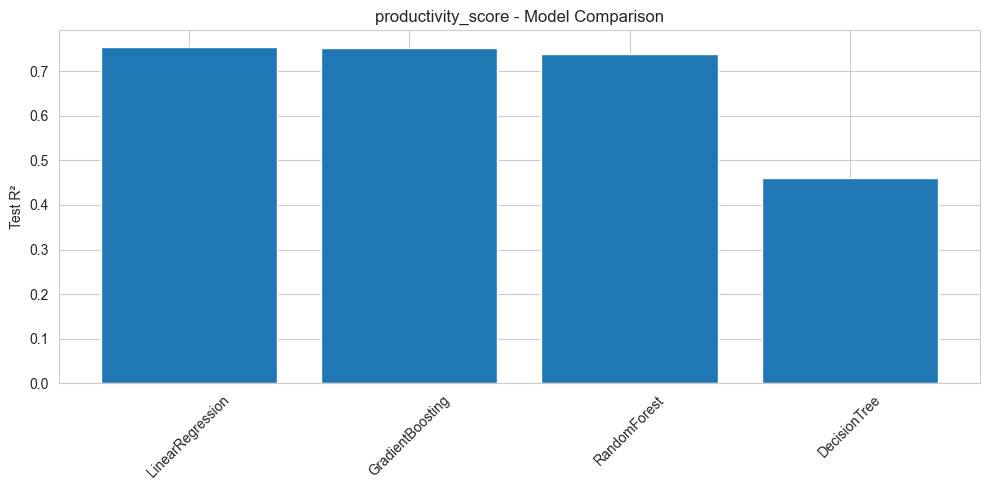


✅ Best model saved as productivity_model.pkl


In [36]:
best_productivity_model = train_and_compare_models(
    df_model,
    target_column="productivity_score",
    model_save_name="productivity_model.pkl"
)


🎯 TARGET: focus_index

🔹 Training LinearRegression...
Train R²: 0.8383
Test R²:  0.8032
RMSE:     4.3168
MAE:      3.1838
Overfit:  0.0351

🔹 Training DecisionTree...
Train R²: 1.0000
Test R²:  0.9452
RMSE:     2.2776
MAE:      1.4532
Overfit:  0.0548

🔹 Training RandomForest...
Train R²: 0.9980
Test R²:  0.9778
RMSE:     1.4495
MAE:      0.7325
Overfit:  0.0202

🔹 Training GradientBoosting...
Train R²: 0.9792
Test R²:  0.9600
RMSE:     1.9470
MAE:      1.4020
Overfit:  0.0193

📊 MODEL COMPARISON


,Model,Train R²,Test R²,RMSE,MAE,Overfit
2,RandomForest,0.997980,0.977813,1.449534,0.732533,0.020167
3,GradientBoosting,0.979243,0.959972,1.946984,1.402011,0.019271
1,DecisionTree,1.000000,0.945224,2.277588,1.453250,0.054776
0,LinearRegression,0.838304,0.803234,4.316750,3.183805,0.035071



🏆 BEST MODEL: RandomForest
Test R²: 0.9778
RMSE: 1.4495
MAE: 0.7325


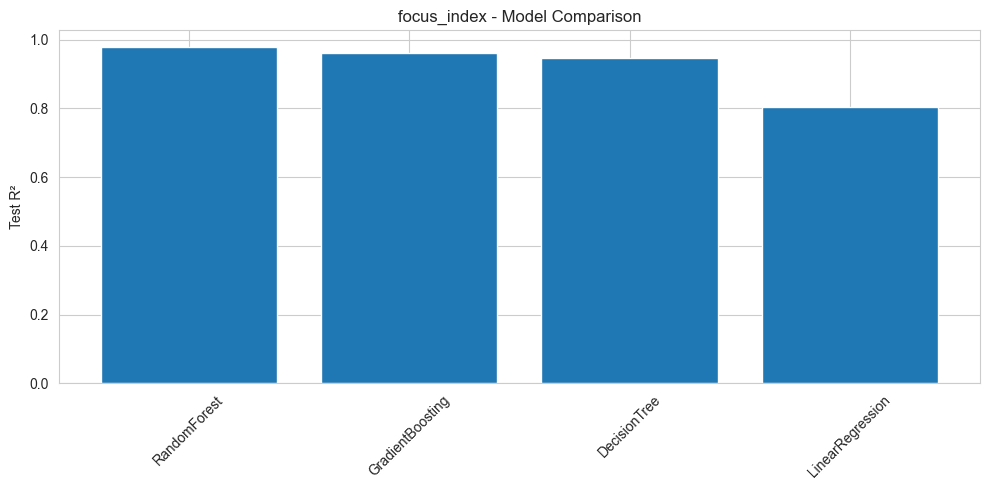


✅ Best model saved as focus_model.pkl


In [37]:
best_focus_model = train_and_compare_models(
    df_model,
    target_column="focus_index",
    model_save_name="focus_model.pkl"
)